In [3]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (LigandEnvironment, 
                BinaryReceptor, 
                generate_receptor_indices, 
                plot_family_summary,
                LogNormalConcentration,
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from objectives import DiscreteProxyLoss
from run import run


In [4]:
CONF = {
        "n_units": 2,
        "n_families": 5,
        "latent_dim": 3,
        "k_sub": 5,
        "batch_size": 1024,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":5,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)
    }

In [5]:
env,loss,physics,stats = run(CONF)

Training for 600 epochs...
Total Correlation: 0.0082
Total Correlation: 0.0484
Total Correlation: 0.0257
Total Correlation: 0.0231
Total Correlation: 0.0147
Total Correlation: 0.0102
Total Correlation: 0.0092
Total Correlation: 0.0111
Total Correlation: 0.0061
Total Correlation: 0.0026
Total Correlation: 0.0016
Total Correlation: 0.0050
Total Correlation: 0.0029
Total Correlation: 0.0002
Total Correlation: 0.0011
Total Correlation: 0.0039
Total Correlation: 0.0023
Total Correlation: 0.0006
Total Correlation: 0.0011
Total Correlation: 0.0009
Total Correlation: 0.0032
Total Correlation: 0.0002
Total Correlation: 0.0004
Total Correlation: 0.0012
Total Correlation: 0.0002
Total Correlation: 0.0032
Total Correlation: 0.0004
Total Correlation: 0.0011
Total Correlation: 0.0015
Total Correlation: 0.0005
Total Correlation: 0.0007
Total Correlation: 0.0004
Total Correlation: 0.0024
Total Correlation: 0.0011
Total Correlation: 0.0009
Total Correlation: 0.0007
Total Correlation: 0.0001
Total Corre

In [6]:
stats.keys()

dict_keys(['full_array_entropy', 'marginal_entropy', 'total_correlation'])

In [7]:
# 1. SETUP
# -----------------------------------------------------
# We use 1 Unit, 1 Family. The receptor is a homopentamer (Unit 0 five times).

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Modules
conc_strategy = LogNormalConcentration(n_families=CONF['n_families'], init_mean=5.0)
env = LigandEnvironment(CONF['n_units'], 
                        CONF['n_families'], 
                        conc_model=conc_strategy,
                        latent_dim=CONF['latent_dim']).to(device)

physics = BinaryReceptor(CONF["n_units"], CONF["k_sub"]).to(device)
#loss_fn = ProxyInformationLoss(cov_weight=CONF['cov_weight']) # Default bandwidth
loss_fn = DiscreteProxyLoss(cov_weight = CONF["cov_weight"],n_bins=CONF['n_bins'],bin_temp=CONF["bin_temp"]) # Default bandwidth

# Create the receptor identity: [[0, 0, 0, 0, 0]]
#receptor_indices = torch.zeros(1, CONF["k_sub"], dtype=torch.long, device=device)
#receptor_indices = generate_receptor_indices(n_units=CONF['n_units'],k_sub= CONF['k_sub'],n_sensors=2)
receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1],[0,0,1,1,1]],dtype=torch.long)
#receptor_indices = torch.tensor([[0,0,0,0,0]],dtype=torch.long)
print(receptor_indices)


# Optimizer
optimizer = optim.Adam(list(env.parameters()) + list(physics.parameters()), lr=CONF["lr"])


tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1]])


(<Figure size 500x400 with 1 Axes>,
 <PolarAxes: title={'center': 'Assembled Receptor Affinity Profile'}>)

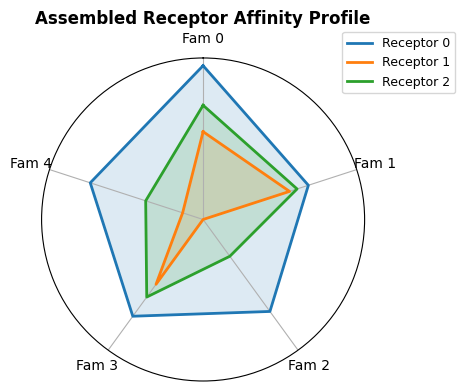

In [9]:
plot_latent_radar_chart(env, receptor_indices, family_names=None)

Fitting UMAP... (This may take a few seconds)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


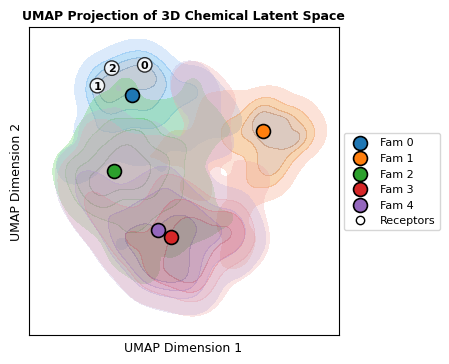

In [5]:
fig,ax = plot_latent_umap(env,receptor_indices=receptor_indices)

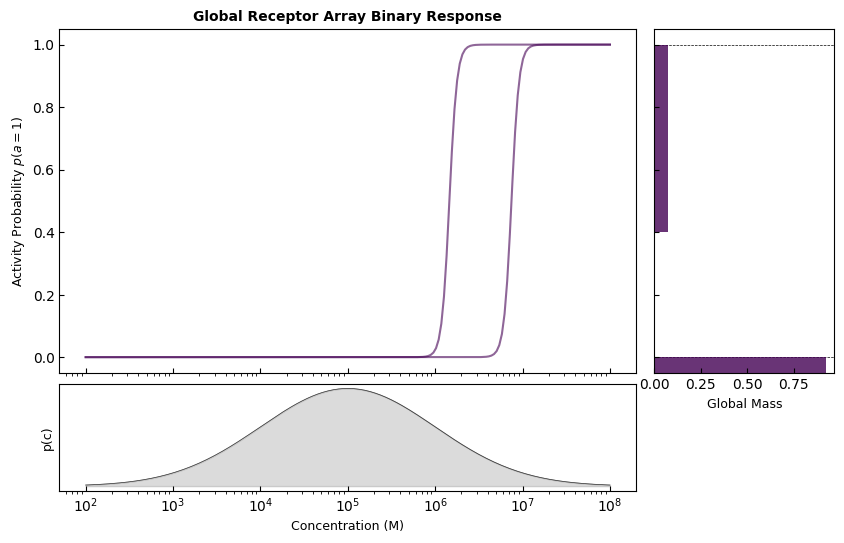

In [7]:
figs,axes = plot_summary(env, physics, receptor_indices, n_points=200)
#with torch.no_grad():
#    E_o = env.interaction_mu.cpu()[:,:,0]
#    E_c = env.interaction_mu.cpu()[:,:,1]
#    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
#for i in range(axes.__len__()):
#    axes[i][0].plot([10**2,10**8],[asymptot[0][i],asymptot[0][i]])
#figs[0].savefig('no_opti_1r_1l.svg',bbox_inches='tight')
#axes[0].set_xscale('log')

In [6]:
# 3. OPTIMIZATION LOOP
# -----------------------------------------------------
print(f"Training for {CONF['epochs']} epochs...")

stats_1 = []
for epoch in range(CONF['epochs']):
    optimizer.zero_grad()
    
    # A. Sample Batch
    # energies: (B, 1, 2), concs: (B,)
    energies, concs, _ = env.sample_batch(CONF['batch_size'])
    
    # B. Physics
    # activity: (B, 1)
    activity = physics(energies, concs, receptor_indices)
    

    # C. Loss (Maximize Entropy)
    loss = loss_fn(activity)
    
    loss.backward()
    optimizer.step()
    
    
    if epoch % 10 == 0:
        stats_1.append(loss_fn.make_stats(activity))
#stats = np.array(stats)
#stats = {
#            "full_array_entropy":stats[:,0],
#            "marginal_entropy":stats[:,1],
#            "total_correlation":stats[:,2]
#        }


Training for 600 epochs...


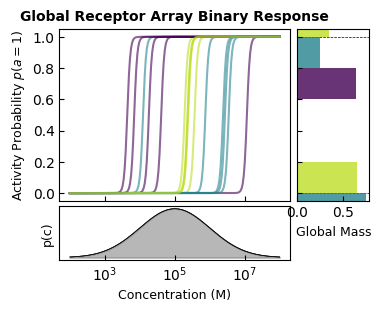

In [8]:
figs,axes = plot_summary(env, physics, receptor_indices)

#with torch.no_grad():
#    E_o = env.interaction_mu.cpu()[:,:,0]
#    E_c = env.interaction_mu.cpu()[:,:,1]
#    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
#for i in range(axes.__len__()):
#    for j in range(asymptot.shape[0]):
#        axes[i][0].plot([10**2,10**8],[asymptot[j][i],asymptot[j][i]])
#for i,fig in enumerate(figs):
#    fig.savefig('2homo_1hetero_'+str(i)+'.svg')
#figs[0].savefig('opti_1r_1l.svg',bbox_inches='tight')

Fitting UMAP... (This may take a few seconds)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


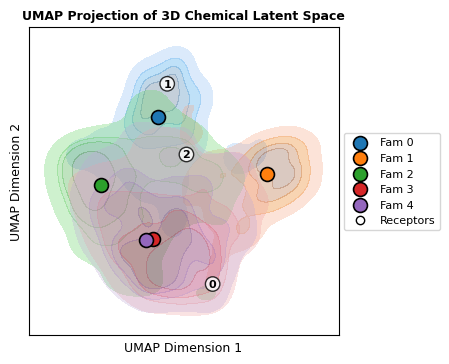

In [7]:
fig,ax = plot_latent_umap(env,receptor_indices=receptor_indices)

(<Figure size 500x400 with 1 Axes>, <PolarAxes: >)

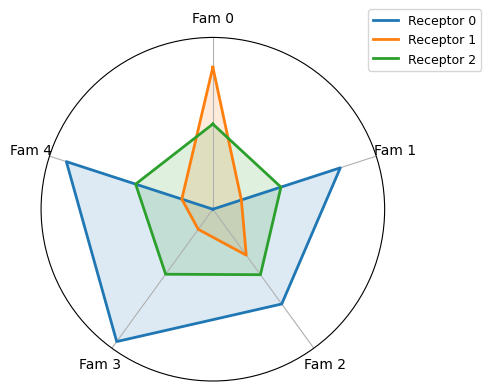

In [9]:
plot_latent_radar_chart(env, receptor_indices, family_names=None)

In [9]:
ents = []
N = [10,100,1000,10000]
# sample a bunch of ligands and store the entropy:
evaluated_ent_1 = list()
for n_samples in N:
    ent = list()
    for _ in range(100):
        ent.append(evaluate_model(env=env,physics=physics,receptor_indices=receptor_indices,loss_fn=loss_fn,n_samples=n_samples,k_knn=5).item())
    evaluated_ent_1.append(ent)

1.9364383220672607


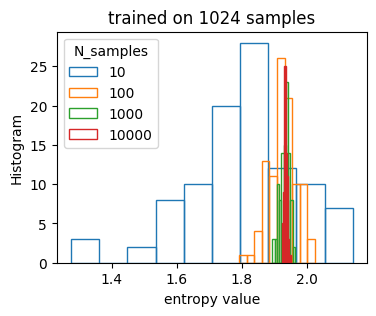

In [10]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for n,ent in zip(N,evaluated_ent_1):
    ax.hist(ent,fill=False,edgecolor=next(colors),label=f'{n}')
ax.set_xlabel('entropy value')
ax.set_ylabel('Histogram')
ax.legend(title='N_samples')
ax.set_title(f'trained on {CONF["batch_size"]} samples')
#fig.savefig(f"histogram_test_{CONFs[0]['batch_size']}.svg",transparent=True,bbox_inches='tight')
print(np.mean(ent[-1]))

In [15]:
np.mean(np.asarray(evaluated_ent_1),axis=1)

array([1.80549823, 1.92669353, 1.93255598, 1.93510435])

Training for 600 epochs...


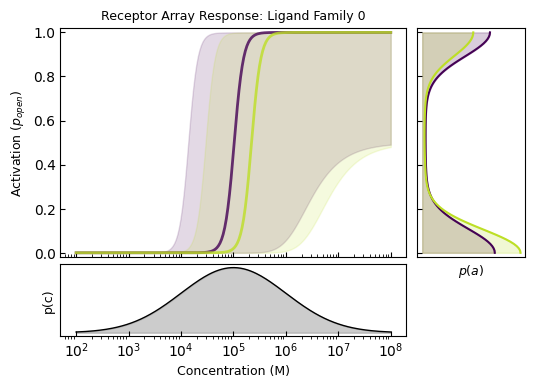

In [47]:
CONF = {
        "n_units": 2,
        "n_families": 1,
        "latent_dim": 1,
        "k_sub": 5,
        "batch_size": 1024,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.,
        "k_knn":5
    }
# 1. SETUP
# -----------------------------------------------------
# We use 1 Unit, 1 Family. The receptor is a homopentamer (Unit 0 five times).

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Modules
conc_strategy = LogNormalConcentration(n_families=CONF['n_families'], init_mean=5.0)
env = LigandEnvironment(CONF['n_units'], 
                        CONF['n_families'], 
                        conc_model=conc_strategy,
                        latent_dim=CONF['latent_dim']).to(device)

physics = Receptor(CONF["n_units"], CONF["k_sub"]).to(device)
loss_fn = ExactInformationLoss(k_knn=CONF['k_knn']) # Default bandwidth

# Create the receptor identity: [[0, 0, 0, 0, 0]]
#receptor_indices = torch.zeros(1, CONF["k_sub"], dtype=torch.long, device=device)
#receptor_indices = generate_receptor_indices(n_units=CONF['n_units'],k_sub= CONF['k_sub'],n_sensors=2)
receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)

# Optimizer
optimizer = optim.Adam(list(env.parameters()) + list(physics.parameters()), lr=CONF["lr"])

# 3. OPTIMIZATION LOOP
# -----------------------------------------------------
print(f"Training for {CONF['epochs']} epochs...")

figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)
figs[0].savefig('no_opti_2r_1l.svg',bbox_inches='tight')

stats_2 = []
for epoch in range(CONF['epochs']):
    optimizer.zero_grad()
    
    # A. Sample Batch
    # energies: (B, 1, 2), concs: (B,)
    energies, concs, _ = env.sample_batch(CONF['batch_size'])
    
    # B. Physics
    # activity: (B, 1)
    activity = physics(energies, concs, receptor_indices)
    

    # C. Loss (Maximize Entropy)
    loss = loss_fn(activity)
    
    loss.backward()
    optimizer.step()
    
    
    if epoch % 10 == 0:
        stats_2.append(loss_fn.make_stats(activity))
#stats = np.array(stats)
#stats = {
#            "full_array_entropy":stats[:,0],
#            "marginal_entropy":stats[:,1],
#            "total_correlation":stats[:,2]
#        }



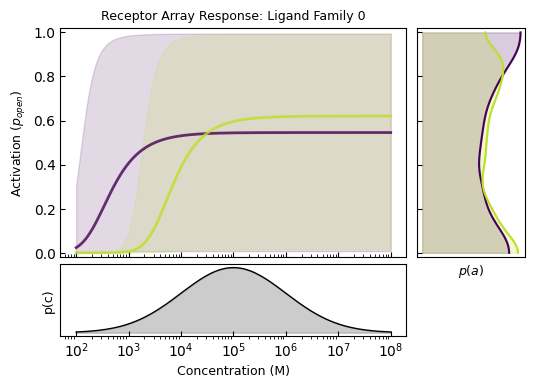

In [49]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)
figs[0].savefig('opti_2r_1l.svg',bbox_inches='tight')
#with torch.no_grad():
#    E_o = env.interaction_mu.cpu()[:,:,0]
#    E_c = env.interaction_mu.cpu()[:,:,1]
#    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
#for i in range(axes.__len__()):
#    for j in range(asymptot.shape[0]):
#        axes[i][0].plot([10**2,10**8],[asymptot[j][i],asymptot[j][i]])

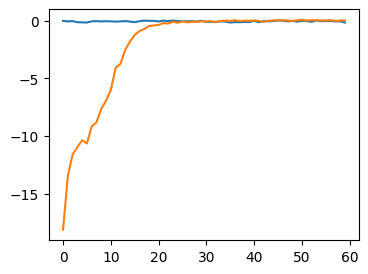

In [40]:
fig,ax= plt.subplots(1,1,figsize=(4,3))
full_array_ent_2 = [stat['full_array_entropy'] for stat in stats_2]
full_array_ent_1= [stat['full_array_entropy'] for stat in stats_1]
plt.plot(full_array_ent_1)
plt.plot(full_array_ent_2)

In [41]:
ents = []
N = [10,100,1000,10000]
# sample a bunch of ligands and store the entropy:
evaluated_ent_2 = list()
for n_samples in N:
    ent = list()
    for _ in range(100):
        ent.append(evaluate_model(env=env,physics=physics,receptor_indices=receptor_indices,loss_fn=loss_fn,n_samples=n_samples,k_knn=5).item())
    evaluated_ent_2.append(ent)

-0.0367671400308609


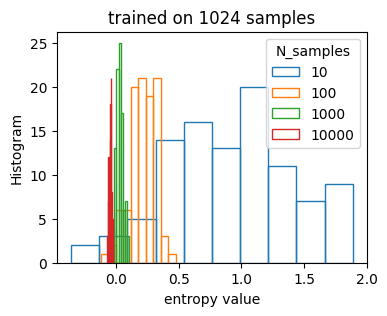

In [42]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for n,ent in zip(N,evaluated_ent_2):
    ax.hist(ent,fill=False,edgecolor=next(colors),label=f'{n}')
ax.set_xlabel('entropy value')
ax.set_ylabel('Histogram')
ax.legend(title='N_samples')
ax.set_title(f'trained on {CONF["batch_size"]} samples')
#fig.savefig(f"histogram_test_{CONFs[0]['batch_size']}.svg",transparent=True,bbox_inches='tight')
print(np.mean(ent[-1]))

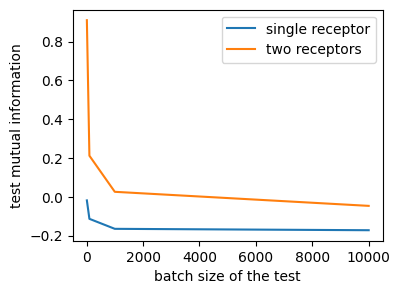

In [46]:
fig,ax = plt.subplots(1,1,figsize=(4,3))

evaluated_ent_1=np.array(evaluated_ent_1)
plt.plot(N,np.mean(evaluated_ent_1,axis=1),label='single receptor')

evaluated_ent_2=np.array(evaluated_ent_2)
plt.plot(N,np.mean(evaluated_ent_2,axis=1),label='two receptors')

plt.ylabel('test mutual information')
plt.xlabel('batch size of the test')

plt.legend()

In [ ]:
full_array_ent_1_hetero = [stat['full_array_entropy'] for stat in stats_1_hetero]
plt.plot(full_array_ent_1_hetero)

In [32]:
full_array_ent_1_hetero = [stat['full_array_entropy'] for stat in stats_1_hetero]
full_array_ent_no_hetero = [stat['full_array_entropy'] for stat in stats_no_hetero]

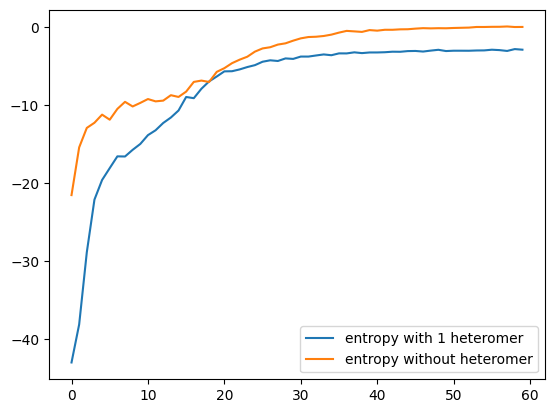

In [33]:
plt.plot(full_array_ent_1_hetero,label="entropy with 1 heteromer")
plt.plot(full_array_ent_no_hetero,label="entropy without heteromer")
plt.legend()

In [11]:
plt.plot(-proxy_loss_history['true_joint_h'],label='approximated loss function')
plt.plot(-exact_loss_history['true_joint_h'],label='exact loss function')
plt.yscale('log')
plt.legend()

NameError: name 'proxy_loss_history' is not defined